In [1]:
pip install pandas joblib shap numpy matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 2.0 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/39.2 MB 6.3 MB/s eta 0:00:07
   --- ------------------------------------ 3.7/39.2 MB 9.9 MB/s eta 0:00:04
   --------- ------------------------------ 9.2/39.2 MB 15.3 MB/s eta 0:00:02
   --------------- ------------------------ 15.2/39.2 MB 19.7 MB/s eta 0:00:02
   ---------------------- ----------------- 21.8/39.2 MB 23.0 MB/s eta 0:00:01
   ------------------------------ --------- 29.6/39.2 MB 26.7 MB/s eta 0:00:01
   ------------------------------------ --- 36.2/39.2 MB 25.8 MB/s eta 0:00:01
   ---------------------------------------- 39.2/39.2 MB 25.4 MB/s  0:00:01
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

c:\Users\Jared\Documents\GitHub\MLG382-Diabetes-Risk-Segmentation-And-Decision-Support-System\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../data/Diabetes_and_LifeStyle_Dataset_.csv')

In [4]:
lifestyle_features = [
    "alcohol_consumption_per_week",
    "physical_activity_minutes_per_week",
    "diet_score",
    "sleep_hours_per_day",
    "screen_time_hours_per_day",
    "bmi",
    "waist_to_hip_ratio",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "cholesterol_total",
    "hdl_cholesterol",
    "ldl_cholesterol",
    "triglycerides",
    "glucose_fasting",
    "glucose_postprandial",
    "insulin_level",
    "hba1c"
    
]
X_seg = df[lifestyle_features]

In [5]:
scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(X_seg)
print("Data shape:", X_seg_scaled.shape)

Data shape: (97297, 18)


lifestyle_segment
1    36597
2    30475
0    30225
Name: count, dtype: int64


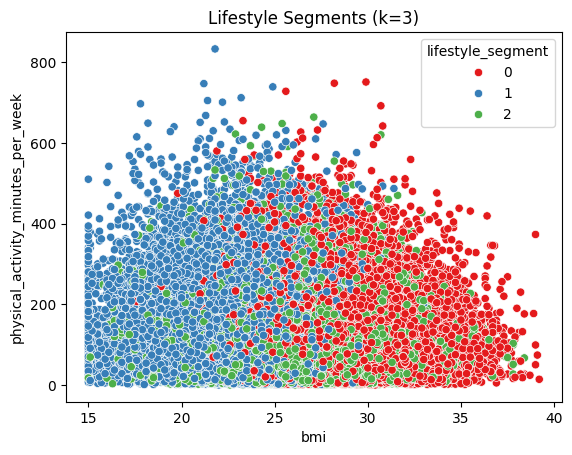

In [6]:
# K-Means Segmentation

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_seg_scaled)

# Add cluster labels to dataframe
df["lifestyle_segment"] = clusters

# Distribution of patients per segment
print(df["lifestyle_segment"].value_counts())

# Visualize clusters (BMI vs Physical Activity)
sns.scatterplot(
    x=df["bmi"],
    y=df["physical_activity_minutes_per_week"],
    hue=df["lifestyle_segment"],
    palette="Set1"
)
plt.title("Lifestyle Segments (k=3)")
plt.show()

## SHAP Explaination
In order to understand why a patient was assigned to a specific segment, we need to train a Random Forest Surrogate Model.Analyzing this model with SHAP, we are able to rank the health metrics that act as the primary "drivers" for our patient segmentation.

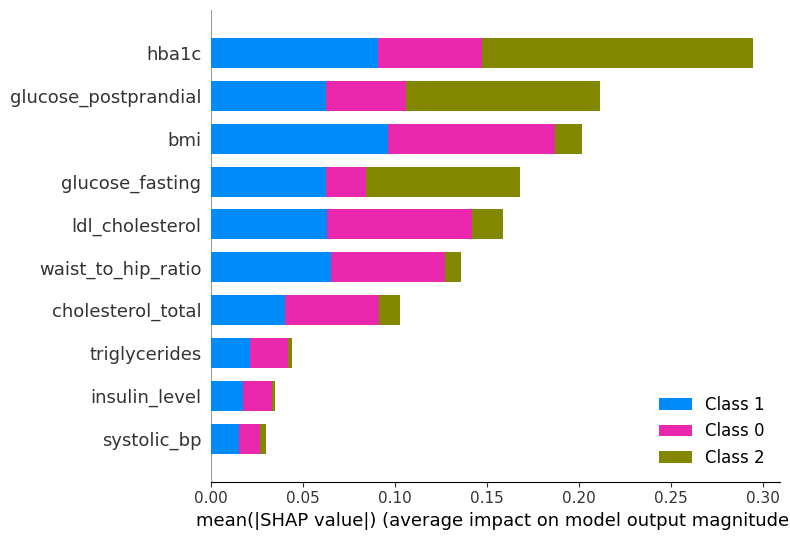

In [7]:

# Train a lighter RandomForest surrogate model
rf_seg = RandomForestClassifier(
    n_estimators=1000,   # fewer trees for speed
    max_depth=5,       # shallow trees
    random_state=42
)
rf_seg.fit(X_seg_scaled, df["lifestyle_segment"])

# Use TreeExplainer with approximate mode for faster computation
explainer_seg = shap.TreeExplainer(rf_seg)
shap_values_seg = explainer_seg.shap_values(X_seg_scaled, approximate=True)

# Plot top drivers of segmentation (limit to top 10 features)
shap.summary_plot(shap_values_seg, X_seg, plot_type="bar", max_display=10)

In [8]:
# Save Artifacts
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(rf_seg, '../artifacts/model_2.pkl')
joblib.dump(explainer_seg, '../artifacts/shap_explainer.pkl')

print("SHAP artifacts have been saved successfully.")

SHAP artifacts have been saved successfully.


In [ ]:
import os
import joblib
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import shap

os.makedirs('../artifacts', exist_ok=True)

# Keep this list aligned with segmentation modeling features
lifestyle_features = [
    'alcohol_consumption_per_week',
    'physical_activity_minutes_per_week',
    'diet_score',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'bmi',
    'waist_to_hip_ratio',
    'systolic_bp',
    'diastolic_bp',
    'heart_rate',
    'cholesterol_total',
    'hdl_cholesterol',
    'ldl_cholesterol',
    'triglycerides',
    'glucose_fasting',
    'glucose_postprandial',
    'insulin_level',
    'hba1c'
]

X_seg = df[lifestyle_features]

# Fit scaler + kmeans (k=3)
scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(X_seg)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_seg_scaled)
df['lifestyle_segment'] = clusters

# RF surrogate for SHAP explainability
rf_seg = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf_seg.fit(X_seg_scaled, df['lifestyle_segment'])
explainer_seg = shap.TreeExplainer(rf_seg)

# Unique artifact names (avoid overwriting model file)
joblib.dump(kmeans, '../artifacts/kmeans.pkl')
joblib.dump(scaler, '../artifacts/scaler.pkl')
joblib.dump(lifestyle_features, '../artifacts/lifestyle_features.pkl')
joblib.dump(rf_seg, '../artifacts/model_2.pkl')
joblib.dump(explainer_seg, '../artifacts/shap_explainer.pkl')

# Quick SHAP sanity check
sample = X_seg_scaled[:500]
sv = explainer_seg.shap_values(sample, approximate=True)
print(f'SHAP values computed. Array rank: {np.array(sv).ndim}')
print('Saved: kmeans.pkl, scaler.pkl, lifestyle_features.pkl, model_2.pkl, shap_explainer.pkl')
